In [112]:
import getpass

In [113]:
ngrok_key = getpass.getpass('Enter ngrok key')

Enter ngrok key··········


In [114]:
!pip install streamlit pyngrok

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [116]:
df = pd.read_csv('diabetes.csv')

In [117]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [118]:
df.shape

(768, 9)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [120]:
df['Outcome'].unique()

array([1, 0])

In [121]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [122]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [123]:
df.duplicated().sum()

np.int64(0)

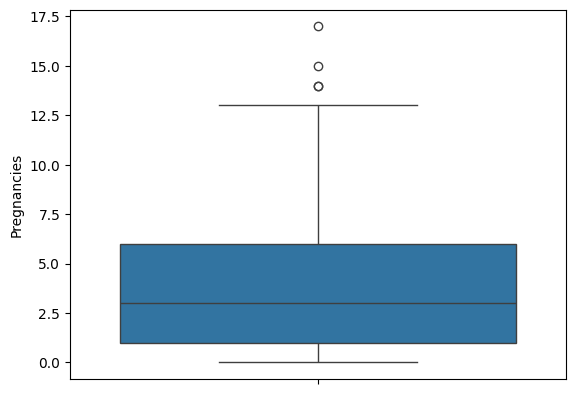

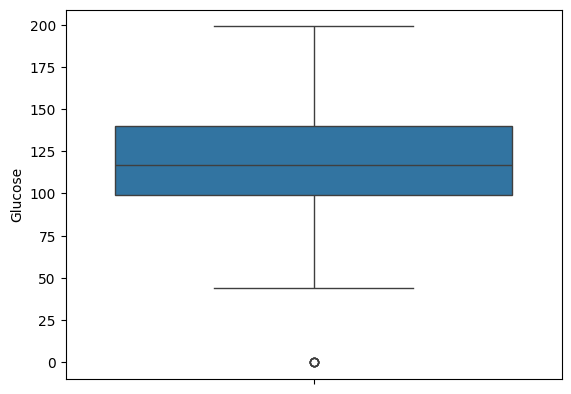

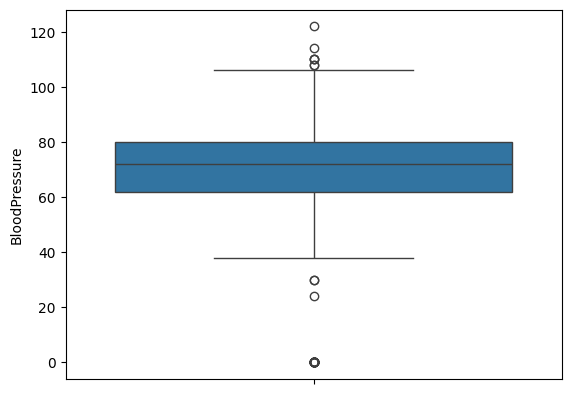

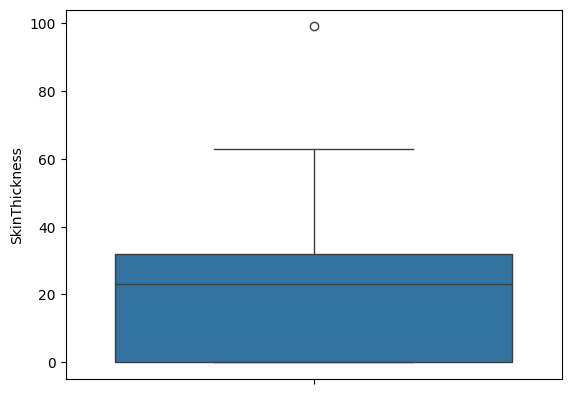

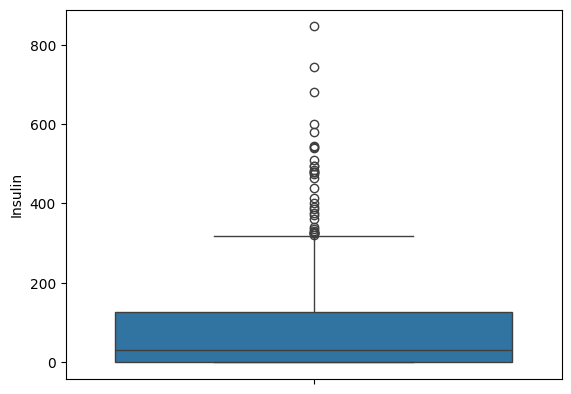

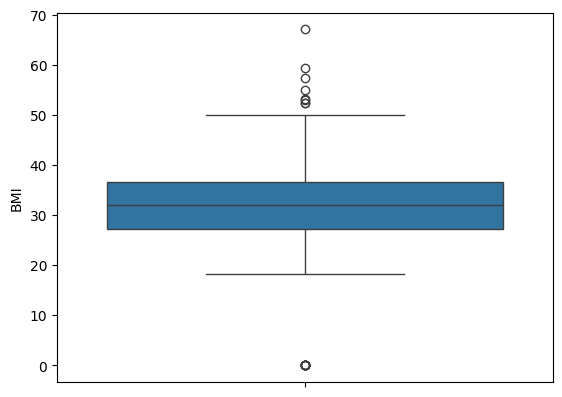

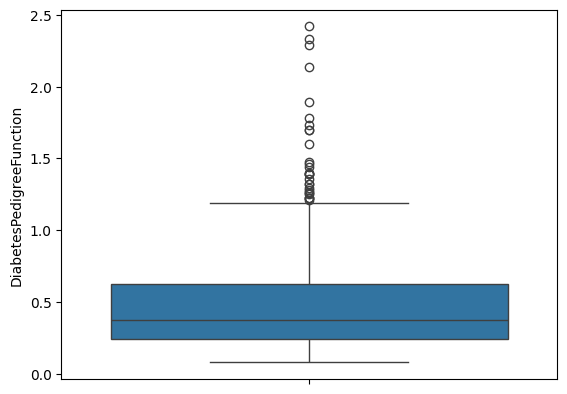

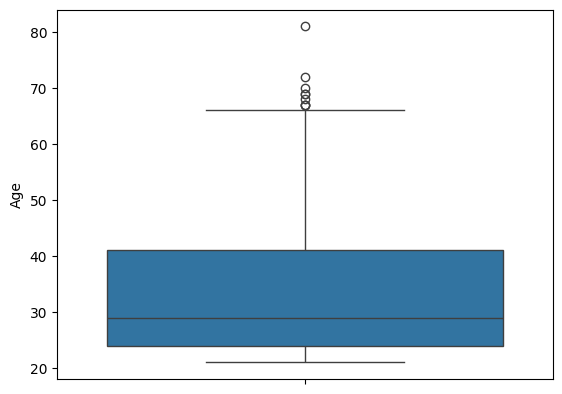

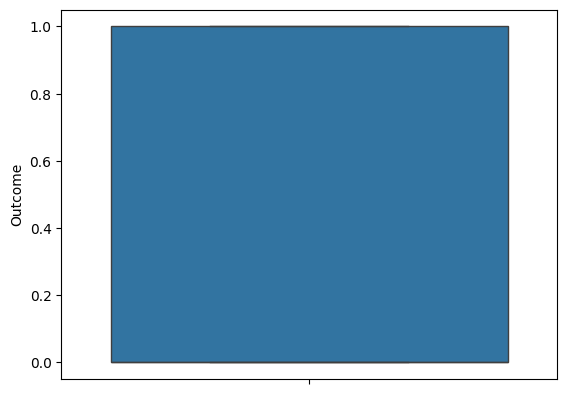

In [124]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [125]:
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else
                                    upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

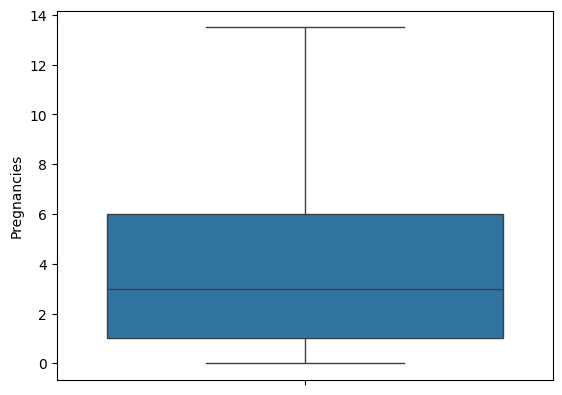

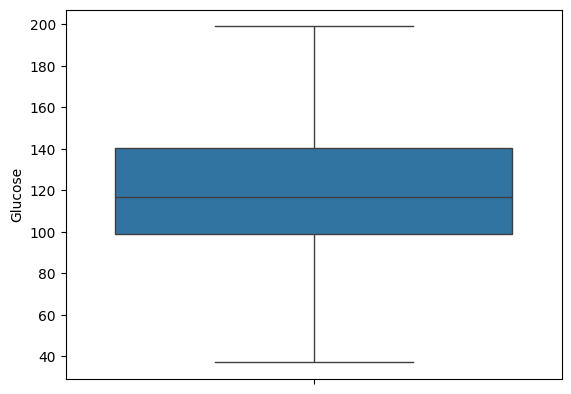

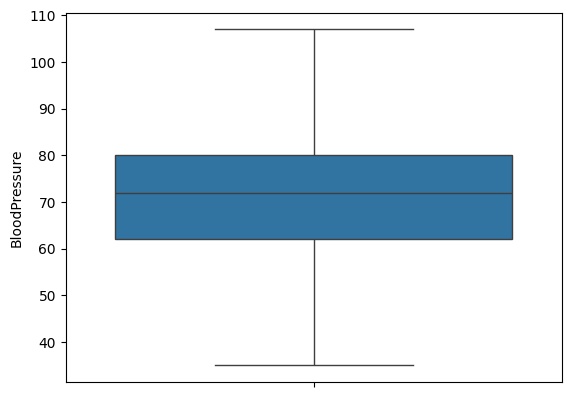

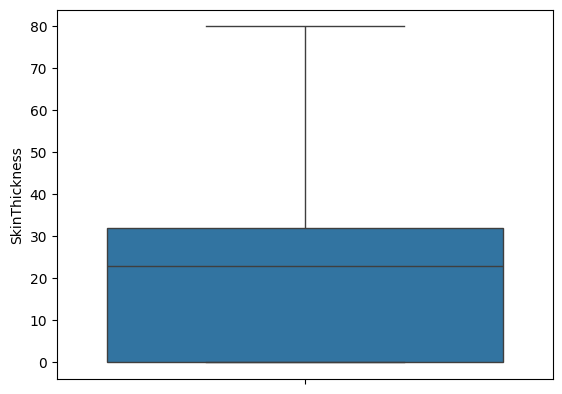

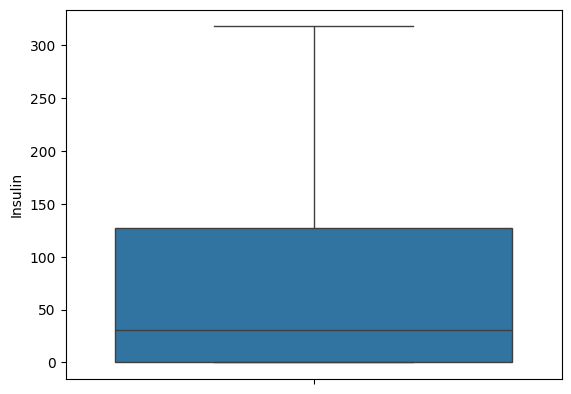

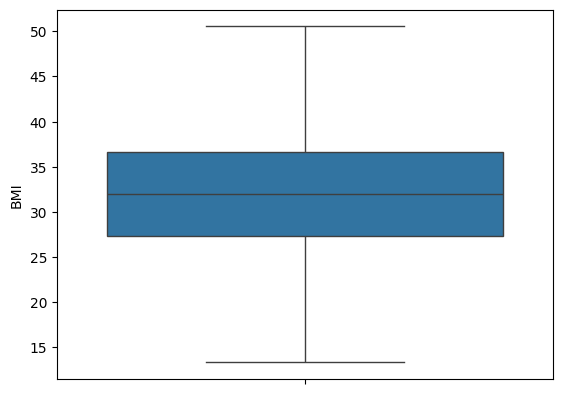

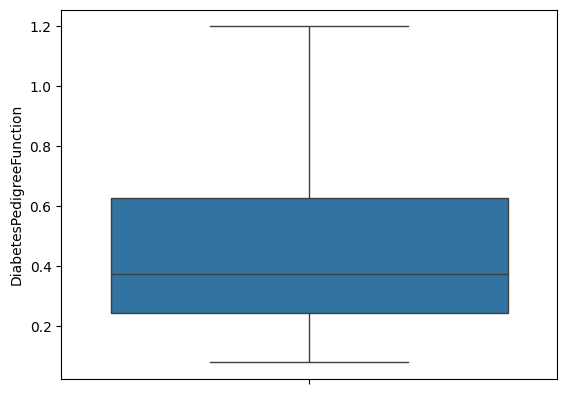

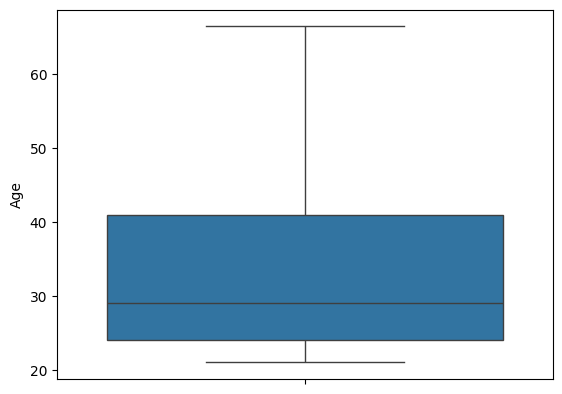

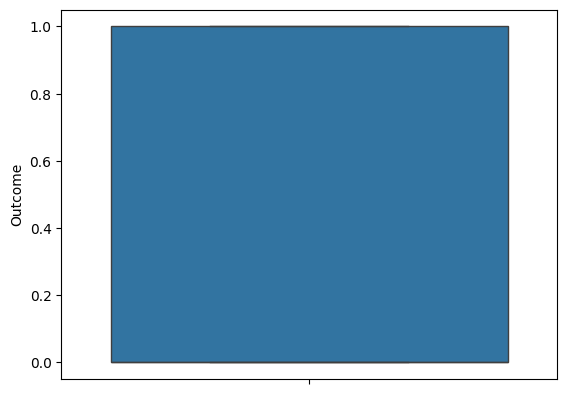

In [126]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [127]:
## correlation
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128987,0.184307,-0.084349,-0.077793,0.024681,-0.017398,0.549695,0.220392
Glucose,0.128987,1.000000,0.197865,0.059806,0.315856,0.235542,0.120213,0.269056,0.479158
BloodPressure,0.184307,0.197865,1.000000,0.152644,0.050080,0.282544,0.038793,0.304208,0.113301
SkinThickness,-0.084349,0.059806,0.152644,1.000000,0.488101,0.401494,0.177920,-0.119170,0.073125
Insulin,-0.077793,0.315856,0.050080,0.488101,1.000000,0.209665,0.190087,-0.065547,0.124721
BMI,0.024681,0.235542,0.282544,0.401494,0.209665,1.000000,0.141087,0.043375,0.309739
DiabetesPedigreeFunction,-0.017398,0.120213,0.038793,0.177920,0.190087,0.141087,1.000000,0.047289,0.184969
Age,0.549695,0.269056,0.304208,-0.119170,-0.065547,0.043375,0.047289,1.000000,0.242702
Outcome,0.220392,0.479158,0.113301,0.073125,0.124721,0.309739,0.184969,0.242702,1.000000


In [128]:
target = df['Outcome']
features = df.drop(columns=['Outcome'])

In [129]:
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


<Axes: >

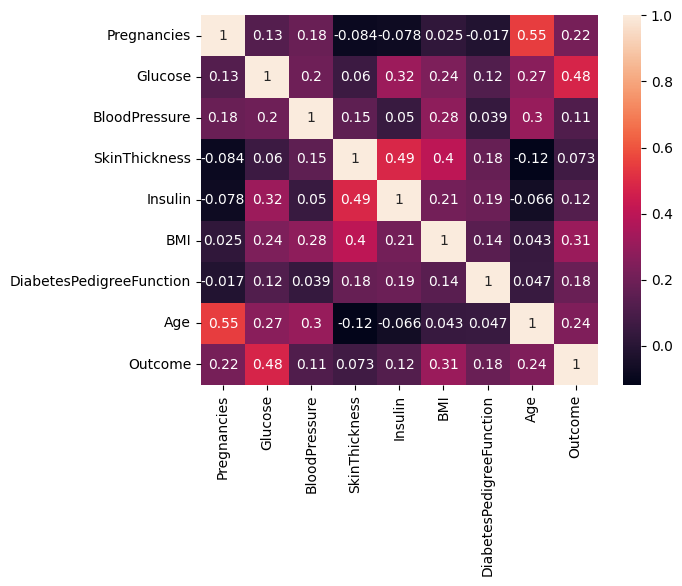

In [130]:
corr = df.corr()
sns.heatmap(corr,annot=True)

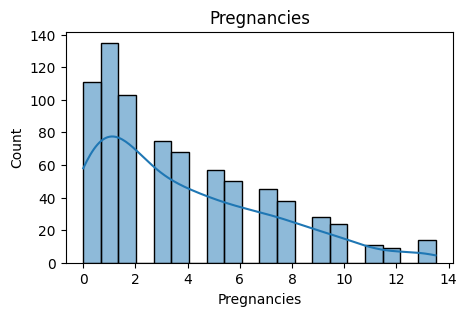

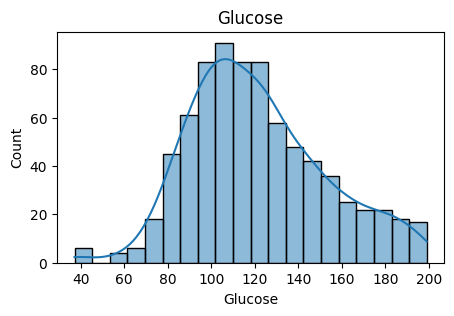

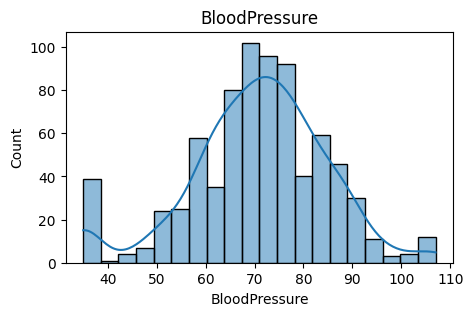

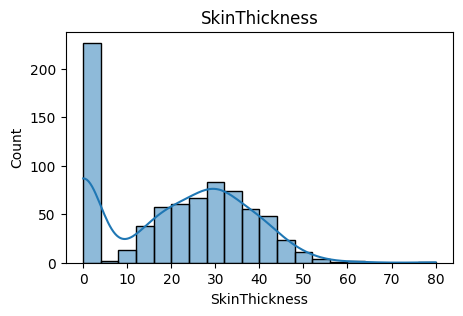

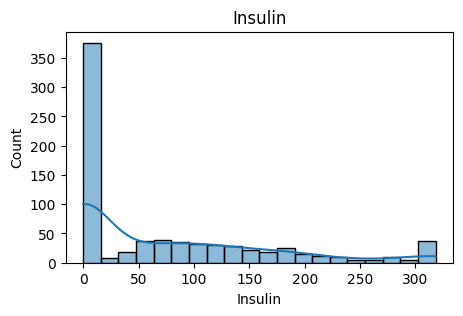

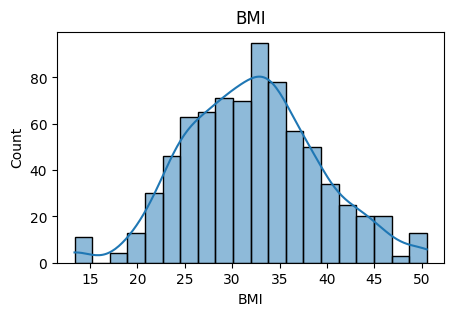

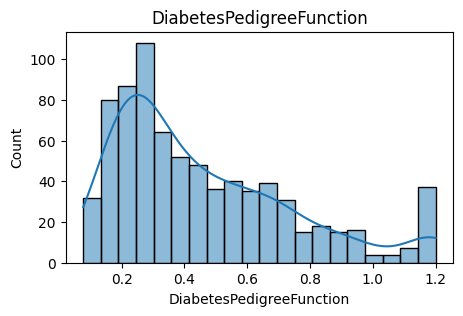

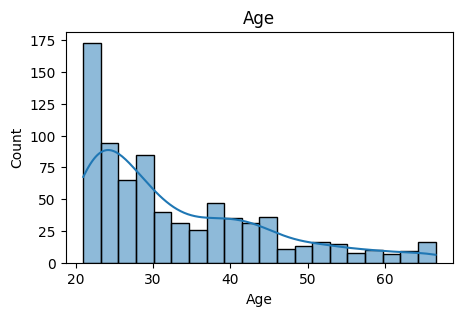

In [131]:
for col in features.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(x=features[col], bins=20,kde=True)
    plt.title(col)
    plt.show()

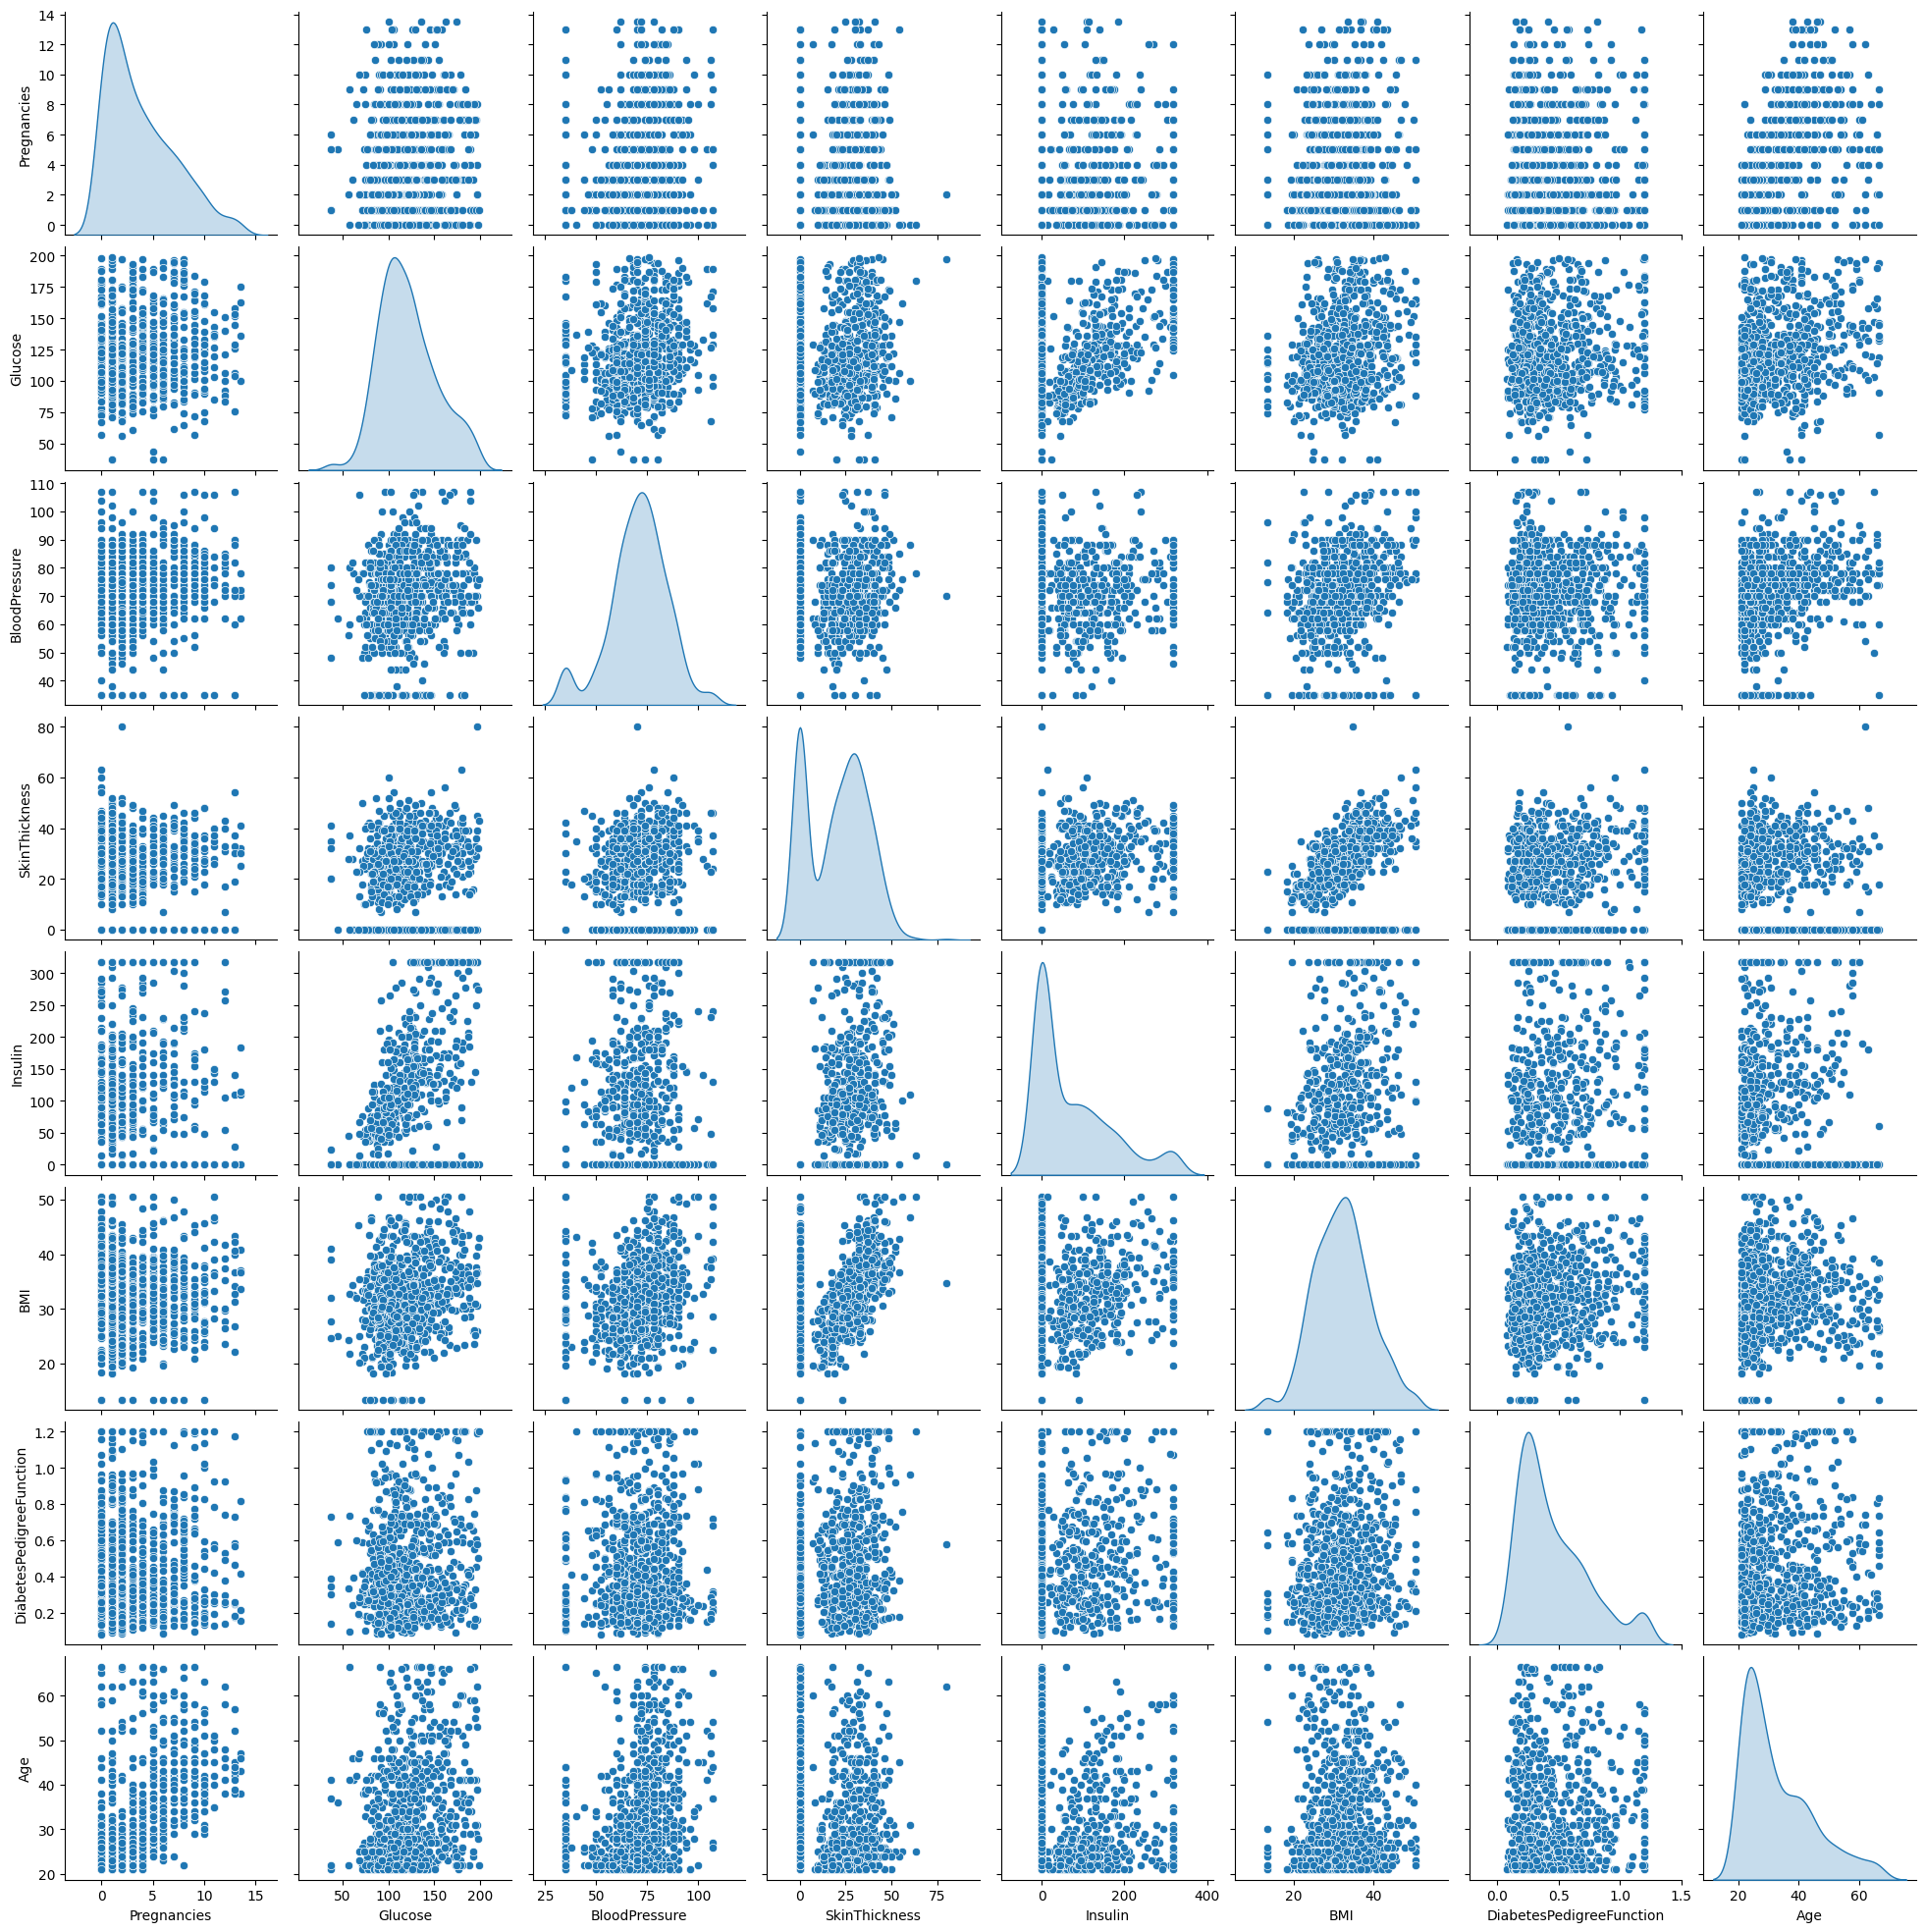

In [132]:
sns.pairplot(features,diag_kind='kde')

In [133]:
## feature selection
from sklearn.feature_selection import f_regression

<Axes: >

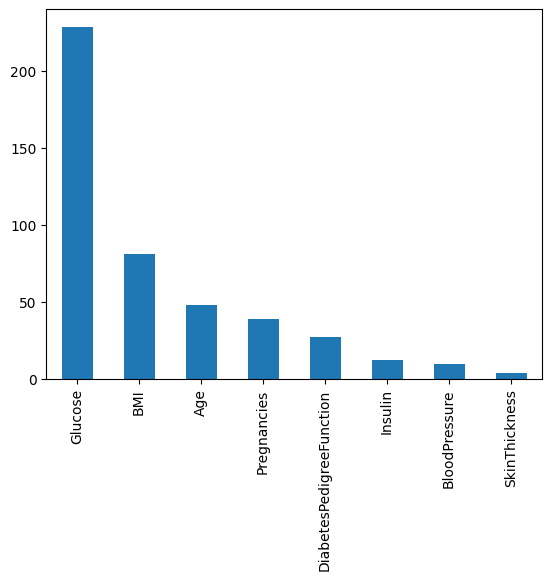

In [134]:
f_reg = f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')

In [135]:
## Multicollinearity checking
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [136]:
vif = pd.DataFrame()
vif['features'] = features.columns
vif['VIF_score'] = [variance_inflation_factor(features.values,i)
                    for i in range(len(features.columns))]
vif

,features,VIF_score
0,Pregnancies,3.319215
1,Glucose,19.086746
2,BloodPressure,24.832962
3,SkinThickness,4.264668
4,Insulin,2.435731
5,BMI,24.035878
6,DiabetesPedigreeFunction,3.750631
7,Age,14.725912


In [137]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [138]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [139]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
660,10.0,162.0,84.0,0.0,0.0,27.7,0.182,54.0
69,4.0,146.0,85.0,27.0,100.0,28.9,0.189,27.0
85,2.0,110.0,74.0,29.0,125.0,32.4,0.698,27.0
219,5.0,112.0,66.0,0.0,0.0,37.8,0.261,41.0
712,10.0,129.0,62.0,36.0,0.0,41.2,0.441,38.0


In [140]:
## scaling
from sklearn.preprocessing import StandardScaler
std_sca = StandardScaler()

In [141]:
x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]= std_sca.fit_transform(x_train[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']])
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
660,1.896506,1.307446,0.949232,-1.267649,-0.770704,-0.593664,-0.944600,1.807381
69,0.075860,0.793186,1.019597,0.413020,0.303034,-0.426860,-0.920181,-0.541350
85,-0.531022,-0.363899,0.245588,0.537514,0.571468,0.059654,0.855435,-0.541350
219,0.379301,-0.299616,-0.317328,-1.267649,-0.770704,0.810275,-0.669013,0.676511
712,1.896506,0.246785,-0.598785,0.973243,-0.770704,1.282888,-0.041094,0.415540


In [142]:
x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]= std_sca.transform(x_test[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']])
x_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
173,-0.834463,-1.360278,-0.739514,1.346725,-0.255310,1.602597,0.785666,-0.889310
253,-1.137904,-1.135289,-0.176599,0.724255,-0.770704,0.532267,-0.749247,-0.715330
207,0.379301,1.307446,2.356522,-1.267649,-0.770704,0.796375,-1.052742,1.633401
737,1.289624,-1.810256,0.104859,0.164032,-0.770704,0.004052,0.513568,0.763501
191,1.593065,0.053937,-0.035870,1.471219,0.238609,0.156957,-0.274820,0.589520


In [143]:
## logistic regression model
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [144]:
log_reg.predict_proba(x_test)

array([[0.81143023, 0.18856977],
       [0.93845233, 0.06154767],
       [0.25120963, 0.74879037],
       [0.89464986, 0.10535014],
       [0.57620945, 0.42379055],
       [0.27582649, 0.72417351],
       [0.03568768, 0.96431232],
       [0.874906  , 0.125094  ],
       [0.08535804, 0.91464196],
       [0.77067665, 0.22932335],
       [0.91248883, 0.08751117],
       [0.11055415, 0.88944585],
       [0.4081032 , 0.5918968 ],
       [0.68598403, 0.31401597],
       [0.25876579, 0.74123421],
       [0.71165313, 0.28834687],
       [0.91998229, 0.08001771],
       [0.75758514, 0.24241486],
       [0.43829977, 0.56170023],
       [0.85353664, 0.14646336],
       [0.75953704, 0.24046296],
       [0.98869679, 0.01130321],
       [0.43798998, 0.56201002],
       [0.017946  , 0.982054  ],
       [0.73937924, 0.26062076],
       [0.14386867, 0.85613133],
       [0.49828229, 0.50171771],
       [0.68868473, 0.31131527],
       [0.60185757, 0.39814243],
       [0.41187082, 0.58812918],
       [0.

In [145]:
## Final predicted values
y_pred = log_reg.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [146]:
## Final accuracy score
accuracy_score(y_test,y_pred)

0.7337662337662337

In [147]:
## Predicted values after changing threshold value
y_pred1 = [1 if x[1]>=0.4 else 0 for x in log_reg.predict_proba(x_test)]
print(y_pred1)

[0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [148]:
## accuracy score after changing threshold value
accuracy_score(y_test,y_pred1)

0.7077922077922078

In [149]:
from sklearn.metrics import confusion_matrix, classification_report

In [150]:
sigmoid = log_reg.predict_proba(x_test)[:,1]
sigmoid

array([0.18856977, 0.06154767, 0.74879037, 0.10535014, 0.42379055,
       0.72417351, 0.96431232, 0.125094  , 0.91464196, 0.22932335,
       0.08751117, 0.88944585, 0.5918968 , 0.31401597, 0.74123421,
       0.28834687, 0.08001771, 0.24241486, 0.56170023, 0.14646336,
       0.24046296, 0.01130321, 0.56201002, 0.982054  , 0.26062076,
       0.85613133, 0.50171771, 0.31131527, 0.39814243, 0.58812918,
       0.04575168, 0.96656203, 0.16320322, 0.52266613, 0.21788735,
       0.33355674, 0.93368196, 0.02581383, 0.19134914, 0.29059619,
       0.33263806, 0.84005308, 0.43830992, 0.08914256, 0.26223742,
       0.93303607, 0.08807158, 0.22351416, 0.9047949 , 0.8927779 ,
       0.0961068 , 0.04139333, 0.32986772, 0.78553706, 0.77292954,
       0.90568296, 0.10397683, 0.05851452, 0.82259607, 0.09380556,
       0.16966608, 0.15271932, 0.30898016, 0.32154223, 0.40321852,
       0.26824808, 0.16476826, 0.02425484, 0.2133538 , 0.02661201,
       0.01733699, 0.6949126 , 0.10157956, 0.24081234, 0.15752

In [151]:
conf = confusion_matrix(y_test,y_pred)
conf

array([[85, 16],
       [25, 28]])

In [152]:
## precision, recall, f1-score
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81       101
           1       0.64      0.53      0.58        53

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



In [153]:
from sklearn.metrics import roc_auc_score, roc_curve

In [154]:
auc_score = roc_auc_score(y_test,sigmoid)
auc_score

np.float64(0.7788156174107976)

In [155]:
## roc_score
roc_curve(y_test,sigmoid)

(array([0.        , 0.        , 0.00990099, 0.00990099, 0.01980198,
        0.01980198, 0.02970297, 0.02970297, 0.04950495, 0.04950495,
        0.06930693, 0.06930693, 0.08910891, 0.08910891, 0.0990099 ,
        0.0990099 , 0.10891089, 0.10891089, 0.12871287, 0.12871287,
        0.13861386, 0.13861386, 0.17821782, 0.17821782, 0.20792079,
        0.20792079, 0.21782178, 0.21782178, 0.22772277, 0.22772277,
        0.23762376, 0.23762376, 0.24752475, 0.24752475, 0.25742574,
        0.25742574, 0.28712871, 0.28712871, 0.32673267, 0.32673267,
        0.33663366, 0.33663366, 0.34653465, 0.34653465, 0.41584158,
        0.41584158, 0.47524752, 0.47524752, 0.48514851, 0.48514851,
        0.55445545, 0.55445545, 0.61386139, 0.61386139, 0.63366337,
        0.63366337, 0.66336634, 0.66336634, 0.68316832, 0.68316832,
        0.7029703 , 0.7029703 , 0.77227723, 0.77227723, 1.        ]),
 array([0.        , 0.01886792, 0.01886792, 0.18867925, 0.18867925,
        0.22641509, 0.22641509, 0.24528302, 0.

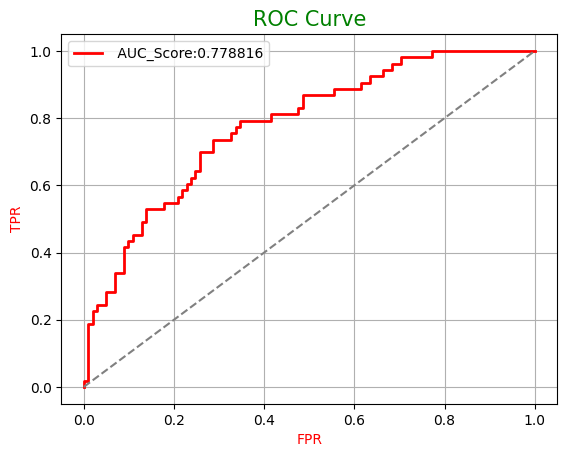

In [156]:
## roc_curve
fpr,tpr,thr = roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,lw=2,color='red',label=f' AUC_Score:{auc_score:2f}')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('FPR',color='red',size=10)
plt.ylabel('TPR',color='red',size=10)
plt.title('ROC Curve',color='green',size=15)
plt.legend()
plt.grid()
plt.show()

In [157]:
coef = pd.DataFrame(log_reg.coef_[0],index=x_train.columns,columns=['Coefficient'])
coef = coef.sort_values(by= 'Coefficient',ascending=False)
coef

,Coefficient
Glucose,1.175736
BMI,0.736791
DiabetesPedigreeFunction,0.451576
Pregnancies,0.348317
Age,0.230889
Insulin,-0.081326
SkinThickness,-0.092080
BloodPressure,-0.144935


In [158]:
import pickle

In [159]:
file = 'Logist_Reg.pkl'
file2 = 'Scaling.pkl'

In [160]:
pickle.dump(log_reg,open(file,'wb'))
pickle.dump(std_sca,open(file2,'wb'))

In [161]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

# Load model and scaler
model = pickle.load(open('Logist_Reg.pkl','rb'))
scale = pickle.load(open('Scaling.pkl','rb'))

st.title("Diabetes Prediction App")

def user_input_parameter():
    Glucose = st.sidebar.number_input('Enter your Glucose Level')
    BMI = st.sidebar.number_input('Enter your BMI')
    DPF = st.sidebar.number_input('Enter Diabetes Pedigree Function')
    Pregnancies = st.sidebar.slider('Pregnancies',0,20)
    Age = st.sidebar.slider('Age',0,100)
    Insulin = st.sidebar.number_input('Insulin')
    SkinThickness = st.sidebar.number_input('Skin Thickness')
    BP = st.sidebar.number_input('Blood Pressure')

    data = {
        'Pregnancies': Pregnancies,
        'Glucose': Glucose,
        'BloodPressure': BP,
        'SkinThickness': SkinThickness,
        'Insulin': Insulin,
        'BMI': BMI,
        'DiabetesPedigreeFunction': DPF,
        'Age': Age
    }

    features = pd.DataFrame(data, index=[0])

    features[['Pregnancies','Glucose','BloodPressure','SkinThickness',
              'Insulin','BMI','DiabetesPedigreeFunction','Age']] = \
    scale.transform(features[['Pregnancies','Glucose','BloodPressure','SkinThickness',
                              'Insulin','BMI','DiabetesPedigreeFunction','Age']])

    return features

input_df = user_input_parameter()
prediction = model.predict(input_df)
prob = model.predict_proba(input_df)

st.subheader("Prediction")
if prediction[0] == 1:
    st.write("Diabetic")
else:
    st.write("Not Diabetic")

st.subheader("Prediction Probability")
st.write(prob)

Overwriting app.py


In [165]:
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [166]:
from pyngrok import ngrok
ngrok.set_auth_token(ngrok_key)
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://rematch-ice-sublease.ngrok-free.dev" -> "http://localhost:8501"


In [164]:
##!rm -rf logs.txt && streamlit run app.py &>/content/logs.txt

1. What is the difference between precision and recall?
2. What is cross-validation, and why is it important in binary classification?


1. Precision:-
Out of all predicted positives, how many are actually correct that is precision. And main focus is avoid false positive
   Recall:-
Out of all actual positives, how many did the model correctly find that is Recall. And main focus is avoid false negatives.

2. Cross Validation:-
Cross-validation is a technique to evaluate model performance by splitting data into multiple training and testing sets.
- Better model evaluation. Not dependent on a single train-test split
- Reduce overfitting risk. Model is tested on different subsets
- Uses data efficiently. Every data point is used for both training and testing